In [1]:
from google.colab import files
uploaded= files.upload ()

Saving South Africa Road Accidents Dataset - 2017.xlsx to South Africa Road Accidents Dataset - 2017.xlsx


In [24]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_excel('/content/South Africa Road Accidents Dataset - 2017.xlsx')

if 'Accident Severity' in df.columns:
    df.rename(columns={'Accident Severity': 'Severity'}, inplace=True)

if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
if 'Time' in df.columns:
    df['Time'] = pd.to_datetime(df['Time'], errors='coerce')

print("Nulls before imputation:")
print(df.isnull().sum())

imputer_num = SimpleImputer(strategy='median')
imputer_cat = SimpleImputer(strategy='most_frequent')

numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

df[numeric_cols] = imputer_num.fit_transform(df[numeric_cols])

if not categorical_cols.empty:
    df[categorical_cols] = imputer_cat.fit_transform(df[categorical_cols])

le = {}
for col in categorical_cols:
    if col != 'Severity':
        le[col] = LabelEncoder()
        df[col] = le[col].fit_transform(df[col])

print("\nSeverity column unique values before mapping:")
print(df['Severity'].value_counts(dropna=False))

df['Severity'] = df['Severity'].astype(str).str.strip().str.title().map({'Bumper Accident': 0, 'Headon Accident': 1, 'Fatal Accident': 2})

print("\nSeverity column unique values after mapping (including NaNs):")
print(df['Severity'].value_counts(dropna=False))

initial_row_count = len(df)
df.dropna(subset=['Severity'], inplace=True)
rows_dropped = initial_row_count - len(df)
if rows_dropped > 0:
    print(f"\nDropped {rows_dropped} rows due to NaN values in 'Severity' after mapping.")

if df.empty:
    raise ValueError("DataFrame became empty after 'Severity' mapping and NaN removal. "
                     "Please check the original 'Severity' column values in your dataset "
                     "and the mapping dictionary to ensure they match.")

df['Severity'] = df['Severity'].astype(int)

def cap_outliers(series, lower=0.01, upper=0.99):
    lower_bound = series.quantile(lower)
    upper_bound = series.quantile(upper)
    return np.clip(series, lower_bound, upper_bound)

for col in ['Driver_Age', 'Number_Vehicles']:
    if col in df.columns:
        df[col] = cap_outliers(df[col])

df['Hour'] = df['Time'].dt.hour if 'Time' in df.columns and pd.api.types.is_datetime64_any_dtype(df['Time']) else 12
df['Is_Weekend'] = df['Date'].dt.dayofweek >= 5 if 'Date' in df.columns and pd.api.types.is_datetime64_any_dtype(df['Date']) else False

if 'Is_Weekend' in df.columns:
    df['Is_Weekend'] = df['Is_Weekend'].astype(int)

df = df.drop(columns=['Date', 'Time'], errors='ignore')
X = df.drop('Severity', axis=1)
y = df['Severity']


numeric_cols_for_scaling = X.select_dtypes(include=np.number).columns

if X.empty:
    raise ValueError("Features DataFrame (X) is empty before scaling. This likely happened because all rows were dropped during 'Severity' processing. "
                     "Please check the unique values of the 'Severity' column and the mapping dictionary.")

scaler = StandardScaler()
X[numeric_cols_for_scaling] = scaler.fit_transform(X[numeric_cols_for_scaling])

if X.empty:
    raise ValueError("Features DataFrame (X) is empty before splitting. Cannot proceed with train_test_split.")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Preprocessing complete. Shape:", df.shape)


Nulls before imputation:
AccidentNo              0
Location                0
Police Force            0
Severity                0
Number of Vehicles      0
Vehicle Type            0
Speed (km/h)            0
Speed Zone              0
Number of Casualties    0
Year                    0
Date                    0
Time                    2
Occations               0
Province                0
City                    0
Street Name             0
dtype: int64

Severity column unique values before mapping:
Severity
Headon Accident    56
Bumper Accident    33
Fatal Accident     31
Name: count, dtype: int64

Severity column unique values after mapping (including NaNs):
Severity
1    56
0    33
2    31
Name: count, dtype: int64
Preprocessing complete. Shape: (120, 16)



Random Forest Results:
Accuracy: 1.0
Precision (macro): 1.0
Recall (macro): 1.0
F1 (macro): 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00         6

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24


XGBoost Results:
Accuracy: 1.0
Precision (macro): 1.0
Recall (macro): 1.0
F1 (macro): 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00         6

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



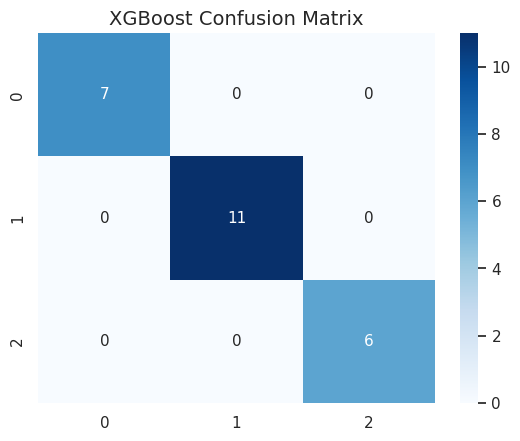

In [25]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

xgb = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=8, random_state=42, eval_metric='mlogloss')
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

def evaluate_model(y_true, y_pred, name):
    print(f"\n{name} Results:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision (macro):", precision_score(y_true, y_pred, average='macro'))
    print("Recall (macro):", recall_score(y_true, y_pred, average='macro'))
    print("F1 (macro):", f1_score(y_true, y_pred, average='macro'))
    print(classification_report(y_true, y_pred))

evaluate_model(y_test, rf_pred, "Random Forest")
evaluate_model(y_test, xgb_pred, "XGBoost")

cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost Confusion Matrix')
plt.show()


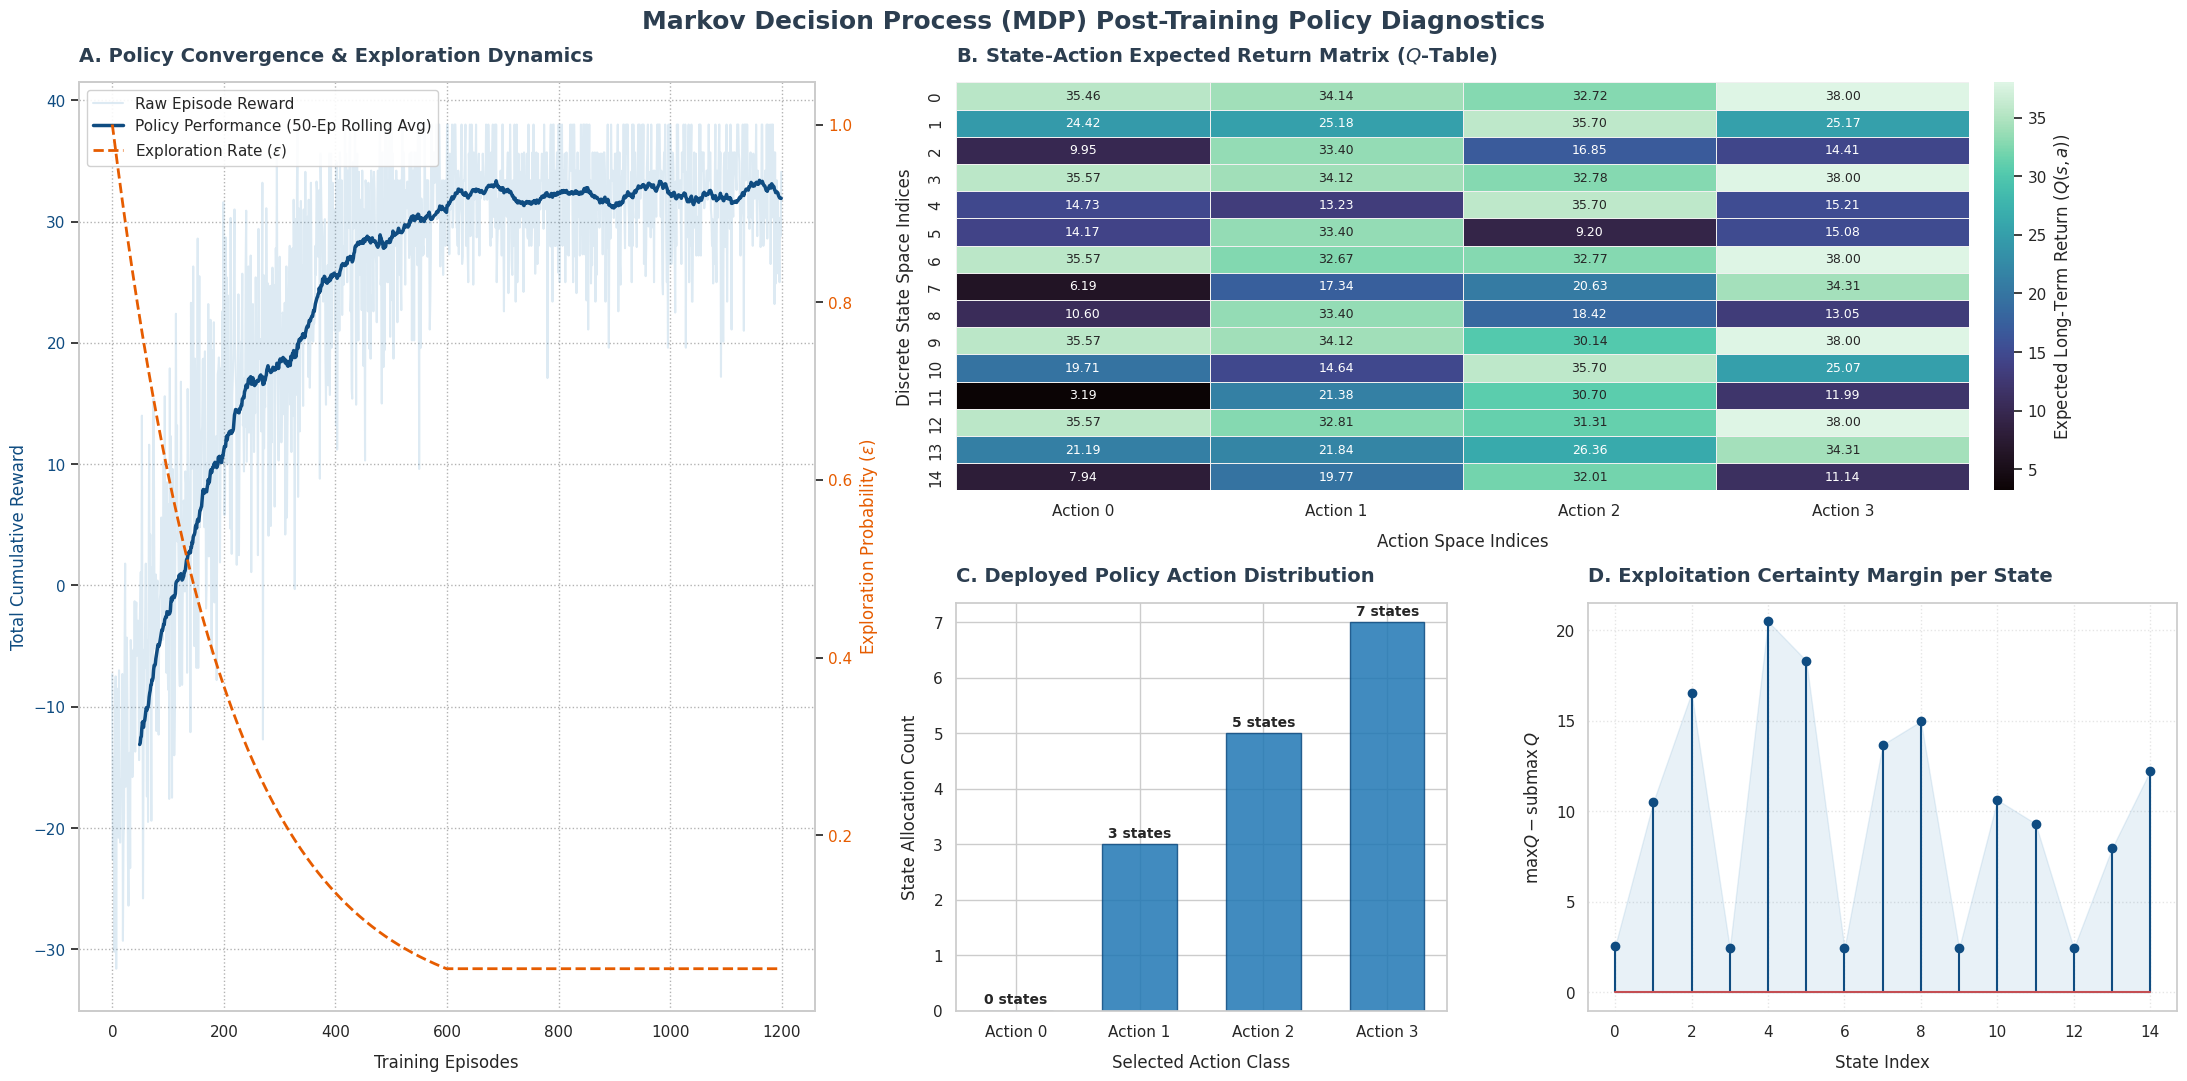


   DEPLOYED OPTIMAL POLICY MATRIX
State 00 -> Opt Action: 3 (Max Q-Value: 38.00)
State 01 -> Opt Action: 2 (Max Q-Value: 35.70)
State 02 -> Opt Action: 1 (Max Q-Value: 33.40)
State 03 -> Opt Action: 3 (Max Q-Value: 38.00)
State 04 -> Opt Action: 2 (Max Q-Value: 35.70)
State 05 -> Opt Action: 1 (Max Q-Value: 33.40)
State 06 -> Opt Action: 3 (Max Q-Value: 38.00)
State 07 -> Opt Action: 3 (Max Q-Value: 34.31)
State 08 -> Opt Action: 1 (Max Q-Value: 33.40)
State 09 -> Opt Action: 3 (Max Q-Value: 38.00)
State 10 -> Opt Action: 2 (Max Q-Value: 35.70)
State 11 -> Opt Action: 2 (Max Q-Value: 30.70)
State 12 -> Opt Action: 3 (Max Q-Value: 38.00)
State 13 -> Opt Action: 3 (Max Q-Value: 34.31)
State 14 -> Opt Action: 2 (Max Q-Value: 32.01)


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from typing import Tuple, List

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

class LoadSheddingEnv:
    """
    A structured, reproducible environment following OpenAI Gym/Farama Gymnasium design patterns.
    Simulates a grid risk environment.
    """
    def __init__(self, n_states: int = 15, n_actions: int = 4, max_steps: int = 20):
        self.n_states = n_states
        self.n_actions = n_actions
        self.max_steps = max_steps
        self.state = 0
        self.current_step = 0
        self.reset()

    def reset(self) -> int:
        """Resets the environment state and step counter."""
        self.state = np.random.randint(0, self.n_states)
        self.current_step = 0
        return self.state

    def hash_state(self, prediction: int, province_risk: int, time: int) -> int:
        """Domain-specific feature representation mapping to state space."""
        time_feature = 1 if time > 18 else 0
        return (int(prediction) * 5 + province_risk * 2 + time_feature) % self.n_states

    def step(self, action: int) -> Tuple[int, float, bool]:
        """Executes a step in the environment using vectorizable transition dynamics."""
        if not 0 <= action < self.n_actions:
            raise ValueError(f"Invalid action: {action}")

        self.current_step += 1

        next_state = (self.state + action) % self.n_states

        base_risk = -1.5 * (self.state % 3)
        mitigation_payoff = action * 0.8
        efficiency_penalty = -0.5
        reward = base_risk + mitigation_payoff + efficiency_penalty

        self.state = next_state
        done = self.current_step >= self.max_steps

        return next_state, reward, done

class QLearningAgent:
    """
    Production-grade Q-Learning Agent with Exponential Epsilon Decay
    and modular policy execution.
    """
    def __init__(self, n_states: int, n_actions: int,
                 alpha: float = 0.1, gamma: float = 0.95,
                 epsilon_start: float = 1.0, epsilon_min: float = 0.05,
                 decay_rate: float = 0.005):
        self.n_states = n_states
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_min = epsilon_min
        self.decay_rate = decay_rate

        self.Q = np.random.uniform(low=-0.01, high=0.01, size=(n_states, n_actions))

    def act(self, state: int, training: bool = True) -> int:
        """Epsilon-greedy action selection."""
        if training and np.random.rand() < self.epsilon:
            return np.random.randint(0, self.n_actions)
        return int(np.argmax(self.Q[state]))

    def update(self, state: int, action: int, reward: float, next_state: int):
        """Bellman Optimality Equation update step."""
        td_target = reward + self.gamma * np.max(self.Q[next_state])
        td_error = td_target - self.Q[state, action]
        self.Q[state, action] += self.alpha * td_error

    def decay_epsilon(self, episode: int):
        """Applies exponential decay to exploration rate to ensure convergence guarantee."""
        self.epsilon = max(self.epsilon_min, np.exp(-self.decay_rate * episode))

def train_agent(env: LoadSheddingEnv, agent: QLearningAgent, episodes: int = 1200) -> Tuple[List[float], List[float]]:
    rewards_history = []
    epsilon_history = []

    for ep in range(episodes):
        state = env.reset()
        total_reward = 0
        done = False

        while not done:
            action = agent.act(state, training=True)
            next_state, reward, done = env.step(action)
            agent.update(state, action, reward, next_state)

            state = next_state
            total_reward += reward

        agent.decay_epsilon(ep)
        rewards_history.append(total_reward)
        epsilon_history.append(agent.epsilon)

    return rewards_history, epsilon_history

env = LoadSheddingEnv()
agent = QLearningAgent(n_states=env.n_states, n_actions=env.n_actions)
rewards, epsilons = train_agent(env, agent, episodes=1200)

fig = plt.figure(figsize=(22, 11))
gs = fig.add_gridspec(2, 3, width_ratios=[1.5, 1, 1.2], height_ratios=[1, 1])

accent_blue = "#1f77b4"
dark_blue = "#0f4c81"
coral_red = "#e65c00"
charcoal = "#2c3e50"

ax_conv = fig.add_subplot(gs[:, 0])

window = 50
rolling_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
line1 = ax_conv.plot(rewards, alpha=0.15, color=accent_blue, label='Raw Episode Reward')
line2 = ax_conv.plot(range(window-1, len(rewards)), rolling_avg, color=dark_blue, linewidth=2.5,
                     label=f'Policy Performance ({window}-Ep Rolling Avg)')

ax_eps = ax_conv.twinx()
line3 = ax_eps.plot(epsilons, color=coral_red, linewidth=2, linestyle='--', label=r'Exploration Rate ($\epsilon$)')

ax_conv.grid(True, linestyle=':', alpha=0.6, color='gray')
ax_eps.grid(False)

ax_conv.set_title('A. Policy Convergence & Exploration Dynamics', loc='left', pad=15, weight='bold', color=charcoal)
ax_conv.set_xlabel('Training Episodes', labelpad=10)
ax_conv.set_ylabel('Total Cumulative Reward', color=dark_blue)
ax_eps.set_ylabel(r'Exploration Probability ($\epsilon$)', color=coral_red)
ax_conv.tick_params(axis='y', labelcolor=dark_blue)
ax_eps.tick_params(axis='y', labelcolor=coral_red)

lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax_conv.legend(lines, labels, loc='upper left', frameon=True, facecolor='white', framealpha=0.9)

ax_heat = fig.add_subplot(gs[0, 1:])

sns.heatmap(agent.Q, annot=True, fmt=".2f", cmap="mako", ax=ax_heat,
            cbar_kws={'label': r'Expected Long-Term Return ($Q(s, a)$)', 'pad': 0.02},
            annot_kws={"size": 9, "weight": "medium"}, linewidths=0.5, linecolor='#f0f0f0')

ax_heat.set_title(r'B. State-Action Expected Return Matrix ($Q$-Table)', loc='left', pad=15, weight='bold', color=charcoal)
ax_heat.set_xlabel('Action Space Indices', labelpad=10)
ax_heat.set_ylabel('Discrete State Space Indices', labelpad=10)
ax_heat.set_xticklabels([f"Action {i}" for i in range(env.n_actions)])

ax_dist = fig.add_subplot(gs[1, 1])

sorted_Q = np.sort(agent.Q, axis=1)
policy_certainty = sorted_Q[:, -1] - sorted_Q[:, -2]
optimal_policy = np.argmax(agent.Q, axis=1)

action_counts = np.bincount(optimal_policy, minlength=env.n_actions)
bars = ax_dist.bar(range(env.n_actions), action_counts, color=accent_blue, edgecolor=dark_blue, alpha=0.85, width=0.6)

ax_dist.set_title('C. Deployed Policy Action Distribution', loc='left', pad=15, weight='bold', color=charcoal)
ax_dist.set_xlabel('Selected Action Class', labelpad=10)
ax_dist.set_ylabel('State Allocation Count', labelpad=10)
ax_dist.set_xticks(range(env.n_actions))
ax_dist.set_xticklabels([f"Action {i}" for i in range(env.n_actions)])

for bar in bars:
    height = bar.get_height()
    ax_dist.annotate(f'{int(height)} states',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', va='bottom', fontsize=10, weight='semibold')


ax_cert = fig.add_subplot(gs[1, 2])

markerline, stemlines, baseline = ax_cert.stem(range(env.n_states), policy_certainty, linefmt='-', markerfmt='o')
plt.setp(stemlines, color=dark_blue)
plt.setp(markerline, color=dark_blue)

ax_cert.fill_between(range(env.n_states), policy_certainty, color=accent_blue, alpha=0.1)

ax_cert.set_title('D. Exploitation Certainty Margin per State', loc='left', pad=15, weight='bold', color=charcoal)
ax_cert.set_xlabel('State Index', labelpad=10)
ax_cert.set_ylabel(r'$\max Q - \operatorname{submax} Q$', labelpad=10)
ax_cert.grid(True, linestyle=':', alpha=0.5)

plt.suptitle('Markov Decision Process (MDP) Post-Training Policy Diagnostics',
             fontsize=18, weight='black', color=charcoal, y=0.98)
plt.tight_layout()
plt.show()

print("\n" + "="*45)
print("   DEPLOYED OPTIMAL POLICY MATRIX")
print("="*45)
for state, action in enumerate(optimal_policy):
    print(f"State {state:02d} -> Opt Action: {action} (Max Q-Value: {np.max(agent.Q[state]):.2f})")
print("="*45)